## Introduction

The last part of our overarching metric for Quality of Life is how stress-relieving the environment is. I decided to pick a submetric that could be calculated in lots of different ways but I decided to use the number of trees to find this number. Who doesn't love relaxing in nature and breathing fresh, clean air. I did the same thing as the other submetrics where I ended up creating a scaled dataset so that we could factor them into the metric formula. 


In [1]:
import pandas as pd

df_trees = pd.read_csv("Trees.csv", low_memory=False)

conditions = ["Very Good", "Good", "Fair", "Poor", "Critical"]
df_trees_filtered = df_trees[df_trees["condition"].isin(conditions)]

tree_counts_long = (
    df_trees_filtered
    .groupby(["neighborhood", "condition"])
    .size()
    .reset_index(name="Tree_Count")
)

tree_counts_wide = (
    tree_counts_long
    .pivot(index="neighborhood", columns="condition", values="Tree_Count")
    .fillna(0)
    .astype(int)
)

tree_counts_wide["Total_Trees"] = (
    tree_counts_wide["Critical"]
    + tree_counts_wide["Fair"]
    + tree_counts_wide["Good"]
    + tree_counts_wide["Poor"]
    + tree_counts_wide["Very Good"]
)

top10 = (
    tree_counts_wide
    .sort_values("Total_Trees", ascending=False)
    .head(10)
)

print("Top 10 neighborhoods by total number of trees:")
for neighborhood, row in top10.iterrows():
    print(f"\nNeighborhood: {neighborhood}")
    print(f"  Total trees: {row['Total_Trees']}")
    for cond in conditions:
        print(f"  {cond}: {row[cond]}")

Top 10 neighborhoods by total number of trees:

Neighborhood: Squirrel Hill South
  Total trees: 4805
  Very Good: 76
  Good: 1978
  Fair: 1916
  Poor: 777
  Critical: 58

Neighborhood: Highland Park
  Total trees: 2680
  Very Good: 17
  Good: 1116
  Fair: 1083
  Poor: 440
  Critical: 24

Neighborhood: Squirrel Hill North
  Total trees: 1861
  Very Good: 19
  Good: 668
  Fair: 996
  Poor: 168
  Critical: 10

Neighborhood: South Side Flats
  Total trees: 1430
  Very Good: 15
  Good: 890
  Fair: 417
  Poor: 79
  Critical: 29

Neighborhood: Shadyside
  Total trees: 1279
  Very Good: 17
  Good: 311
  Fair: 720
  Poor: 197
  Critical: 34

Neighborhood: East Liberty
  Total trees: 1220
  Very Good: 36
  Good: 450
  Fair: 565
  Poor: 118
  Critical: 51

Neighborhood: Point Breeze
  Total trees: 1152
  Very Good: 17
  Good: 335
  Fair: 667
  Poor: 117
  Critical: 16

Neighborhood: Bloomfield
  Total trees: 1151
  Very Good: 32
  Good: 524
  Fair: 444
  Poor: 126
  Critical: 25

Neighborhood: C

In this cell, I wanted to get a first, basic picture of where trees are located and what shape they are in. I start by filtering the dataset down to trees that have clear condition ratings, then I group by neighborhood and condition to count how many trees fall into each category. Pivoting into a wide table lets me see all the condition levels side by side for each neighborhood, and adding the Total_Trees column gives a simple ranking of which neighborhoods have the most trees overall. Printing the top ten with their breakdowns is like looking at a parts list for a system: it doesn’t yet tell me how those trees are distributed relative to people, but it does show where the raw quantity of greenery is concentrated and how much of it is healthy versus declining.


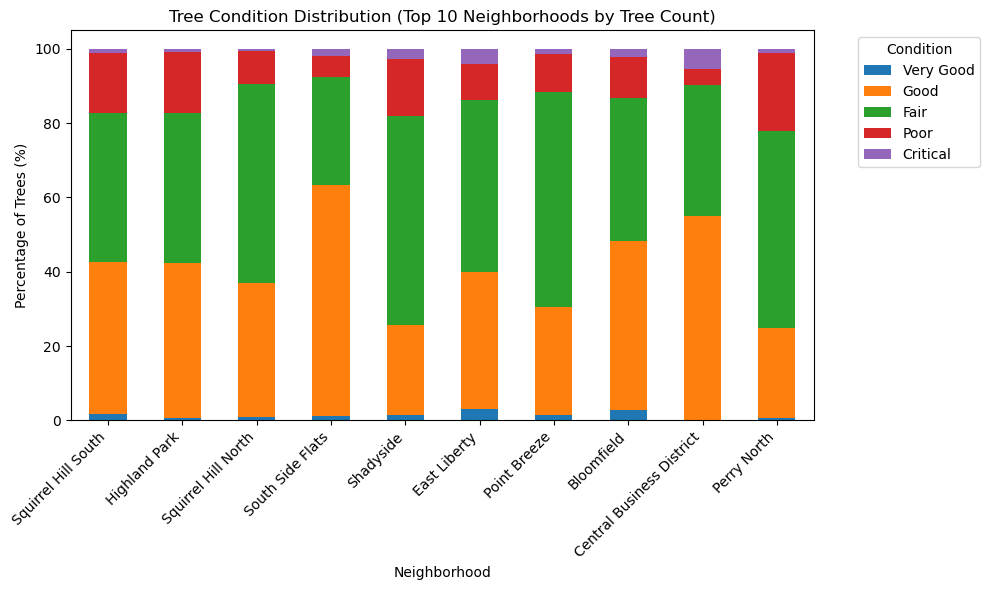

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df_trees = pd.read_csv("Trees.csv", low_memory=False)

conditions = ["Very Good", "Good", "Fair", "Poor", "Critical"]
df_trees_filtered = df_trees[df_trees["condition"].isin(conditions)]

tree_counts_long = (
    df_trees_filtered
    .groupby(["neighborhood", "condition"])
    .size()
    .reset_index(name="Tree_Count")
)

tree_counts_wide = (
    tree_counts_long
    .pivot(index="neighborhood", columns="condition", values="Tree_Count")
    .fillna(0)
    .astype(int)
)

tree_counts_wide["Total_Trees"] = tree_counts_wide[conditions].sum(axis=1)

top10 = (
    tree_counts_wide
    .sort_values("Total_Trees", ascending=False)
    .head(10)
)

top10_percent = top10[conditions].div(top10["Total_Trees"], axis=0) * 100

ax = top10_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.xlabel("Neighborhood")
plt.ylabel("Percentage of Trees (%)")
plt.title("Tree Condition Distribution (Top 10 Neighborhoods by Tree Count)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Condition", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

Here, I take the same top ten neighborhoods by total tree count but shift the focus from raw numbers to the distribution of tree health. Instead of just counting how many trees fall under each condition, I convert those counts into percentages and visualize them with a stacked bar chart. This helps me compare neighborhoods on a qualitative level rather than only a quantitative one. A place with many trees is not necessarily better if most of them are in poor or critical condition. This step is similar to comparing two computers with the same number of components; what matters is not just how many parts they have, but how well those parts actually perform.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# load trees + population data
trees_df = pd.read_csv("Trees.csv", low_memory=False)
pop_df   = pd.read_csv("preliminarycitypittsburghneighborhood_pl94171summary-2.csv", low_memory=False)

# clean the neighborhood field (strip spaces, normalize dashes)
def fix_name(s):
    if pd.isna(s):
        return s
    return s.strip().replace("–", "-").replace("—", "-")

# IMPORTANT: use 'neighborhood' (lowercase) from Trees.csv
trees_df["Neighborhood_norm"] = trees_df["neighborhood"].map(fix_name)
pop_df["Neighborhood_norm"]   = pop_df["Neighborhood"].map(fix_name)

# match Crime notebook's neighborhood merging
combine = {
    "Arlington": "Arlington - Arlington Heights (Combined)",
    "Arlington Heights": "Arlington - Arlington Heights (Combined)",
    "Central Business District": "Central Business District (Downtown)",
    "Chartiers": "Chartiers City",
    "Mount Oliver": "Mt. Oliver",
    "Saint Clair": "St. Clair",
    "Southshore": "South Shore",
    "Spring Hill-City View": "Spring Hill-City"
}

trees_df["Neighborhood_fixed"] = trees_df["Neighborhood_norm"].replace(combine)


In this cell, I bring the trees data into conversation with the population data bystandardizing neighborhood names. The same neighborhood can be written in different ways across datasets, so I normalize spelling and merge specific pairs that are combined in the population file. This is the same approach I used in the crime analysis. I am essentially making sure that when I say “Arlington” or “Central Business District,” both datasets are talking about the exact same place. Without this step, any later attempt to compare trees to population would be misaligned, like plugging a component into the wrong slot on a motherboard.

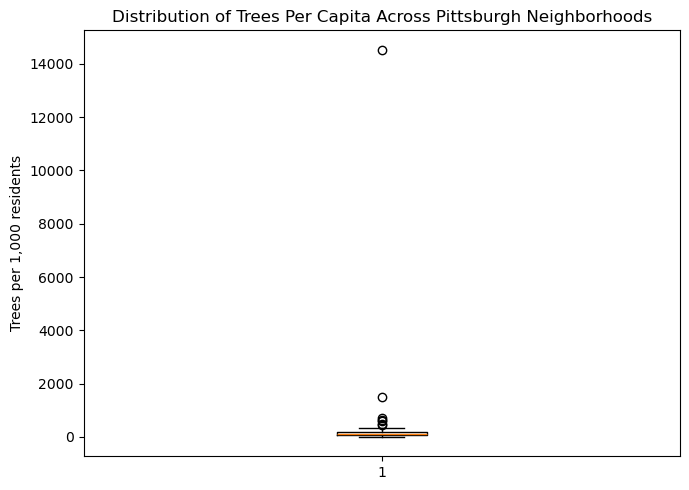

In [6]:
# count number of trees per neighborhood
tree_counts = (
    trees_df
    .dropna(subset=["Neighborhood_fixed"])
    .groupby("Neighborhood_fixed")
    .size()
    .reset_index(name="Tree_Count")
)

# pull 2020 population
pop_2020 = (
    pop_df[["Neighborhood_norm", "2020_Total_Population"]]
    .dropna()
    .rename(columns={"Neighborhood_norm": "Neighborhood_fixed"})
)

# combine population + trees
tree_metrics = tree_counts.merge(pop_2020, on="Neighborhood_fixed", how="inner")
tree_metrics = tree_metrics[tree_metrics["2020_Total_Population"] > 0]

# trees per 1000 residents
tree_metrics["Trees_per_1000"] = (
    tree_metrics["Tree_Count"] / tree_metrics["2020_Total_Population"] * 1000
)

# sort from lowest to highest trees per capita
tree_metrics_sorted = tree_metrics.sort_values("Trees_per_1000", ascending=True)

# boxplot of distribution
plt.figure(figsize=(7, 5))
plt.boxplot(tree_metrics_sorted["Trees_per_1000"], vert=True)
plt.ylabel("Trees per 1,000 residents")
plt.title("Distribution of Trees Per Capita Across Pittsburgh Neighborhoods")
plt.tight_layout()
plt.show()


This cell shifts from total tree counts to tree access per person. I count how many trees fall in each cleaned neighborhood, then join that with the 2020 population totals. Once I have both numbers, I calculate trees per 1,000 residents. This metric asks a more meaningful question: how much greenery does each resident have available in their area? Sorting the neighborhoods and plotting a boxplot of trees per capita shows how uneven that access is across the city. It mirrors the logic I used for crime per 1,000 residents, but here it highlights where the environment is acting as a resource instead of a risk.

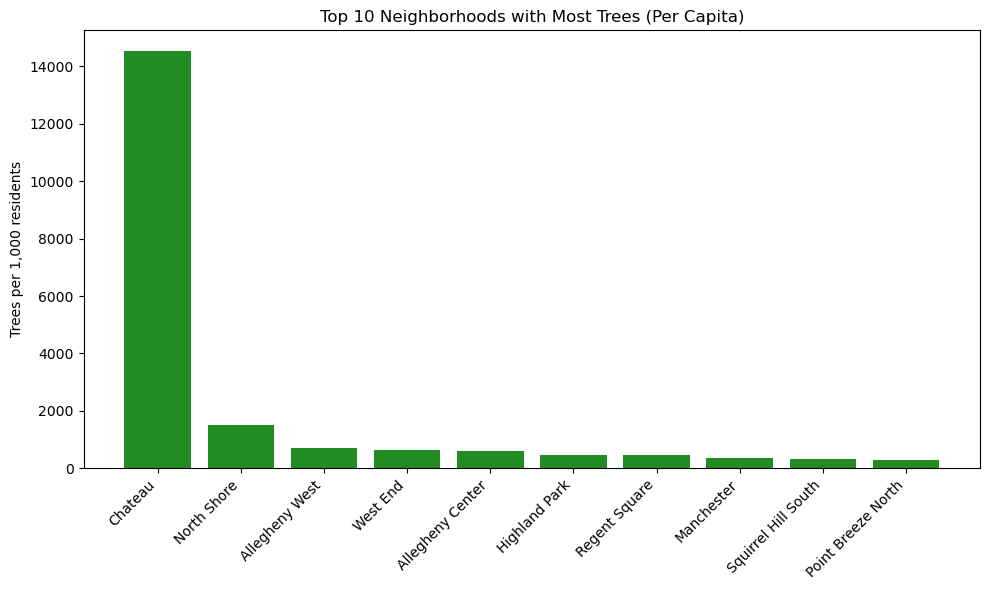

In [7]:
# top 10 neighborhoods for trees per capita
top10_trees = tree_metrics_sorted.sort_values("Trees_per_1000", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.bar(top10_trees["Neighborhood_fixed"], top10_trees["Trees_per_1000"], color="forestgreen")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Trees per 1,000 residents")
plt.title("Top 10 Neighborhoods with Most Trees (Per Capita)")
plt.tight_layout()
plt.show()


Here, I focus on the ten neighborhoods that give residents the most trees per capita. By ranking and plotting these neighborhoods in a bar chart, I can clearly see where tree access is strongest once population size is taken into account. This is different from just listing the neighborhoods with the highest total number of trees, because a smaller area with fewer trees can still provide better access if those trees are more concentrated around residents. This view lines up with how I think about performance in systems: raw capacity matters less than how effectively it is delivered to the people using it.

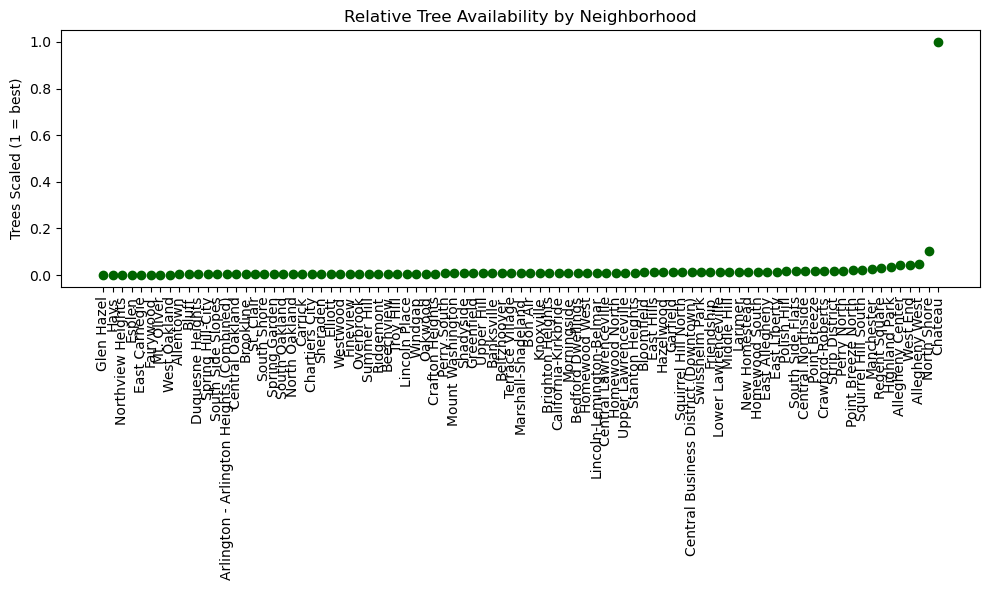

In [8]:
# scale so that 1 = best (most trees), 0 = worst (fewest trees)
t_min = tree_metrics["Trees_per_1000"].min()
t_max = tree_metrics["Trees_per_1000"].max()

if t_max == t_min:
    tree_metrics["Trees_Scaled"] = 1.0
else:
    tree_metrics["Trees_Scaled"] = (
        (tree_metrics["Trees_per_1000"] - t_min) / (t_max - t_min)
    )

# sort again, just to have a clean order for plotting
tree_metrics_sorted2 = tree_metrics.sort_values("Trees_per_1000", ascending=True)

plt.figure(figsize=(10, 6))
plt.scatter(tree_metrics_sorted2["Neighborhood_fixed"], tree_metrics_sorted2["Trees_Scaled"], color="darkgreen")
plt.xticks(rotation=90)
plt.ylabel("Trees Scaled (1 = best)")
plt.title("Relative Tree Availability by Neighborhood")
plt.tight_layout()
plt.show()


In this cell, I convert the trees-per-capita values into a scaled score between zero and one, where one represents the best access to trees and zero represents the weakest access. Since trees improve quality of life instead of harming it, I do not need to invert the scale like I did for crime. The scatter plot then lets me see how each neighborhood sits along this scale. Even though every point is styled the same, the vertical position of each one shows how strong or weak its tree access is relative to others. This step turns the raw environmental data into a clean metric, Trees_Scaled, that can later be combined with other measures in a consistent way.

In [9]:
# ordered from strongest greenery to weakest
tree_final_sorted = tree_metrics.sort_values("Trees_Scaled", ascending=False)

tree_final_sorted.head(15)



,Neighborhood_fixed,Tree_Count,2020_Total_Population,Trees_per_1000,Trees_Scaled
20,Chateau,276,19,14526.315789,1.000000
55,North Shore,457,301,1518.272425,0.104332
1,Allegheny West,386,540,714.814815,0.049010
85,West End,131,205,639.024390,0.043791
0,Allegheny Center,867,1419,610.993658,0.041861
38,Highland Park,2941,6235,471.692061,0.032269
64,Regent Square,434,971,446.961895,0.030567
47,Manchester,707,2031,348.104382,0.023760
75,Squirrel Hill South,5073,15317,331.200627,0.022596
62,Point Breeze North,566,1988,284.708249,0.019395


The goal of this final cell is to organize the neighborhoods from strongest to weakest in terms of their scaled tree access. By sorting on Trees_Scaled and previewing the top fifteen, I can see which neighborhoods lead the city in providing greenery per resident. At this point, trees have been translated from individual entries in a CSV file into a single score that reflects both quantity and fairness of distribution. This table is now in the right form to be merged with similar scaled metrics for crime and complaints, so that trees become one part of a broader quality of life calculation rather than a separate, isolated statistic.

## Conclusion ##

Overall, the trees analys moves from simple counts to which a more in-depth calculation. I looked at which neighborhoods had the most trees and what condition those trees are in but this is still tied to raw totals. By combining the trees data with population, and converting trees per capita into a scaled score, I am able to focus on how much greenery every resident is able to enjoy. Using this I was able to determine that the best stress-relieving neighborhood is **Chateau**. 